🎯 Starting Agile Sprint 2: Advanced Model Training
✅ Engineered data loaded! Shape: (7043, 26)
🚀 Starting advanced model training...
🧹 Preparing data for advanced models...
📋 Encoding 18 categorical columns...
📊 Data prepared:
   Training set: 5634 samples
   Testing set: 1409 samples
   Features: 25

🚀 Training Advanced Models...
📈 Training Random Forest...
   ✅ Random Forest:
      Accuracy: 0.7807
      AUC Score: 0.8220
      CV Score: 0.7858
📈 Training Gradient Boosting...
   ✅ Gradient Boosting:
      Accuracy: 0.8091
      AUC Score: 0.8452
      CV Score: 0.7973
📈 Training XGBoost...
   ✅ XGBoost:
      Accuracy: 0.7807
      AUC Score: 0.8226
      CV Score: 0.7783
📈 Training SVM...
   ✅ SVM:
      Accuracy: 0.7885
      AUC Score: 0.7883
      CV Score: 0.7346
📈 Training K-Nearest Neighbors...
   ✅ K-Nearest Neighbors:
      Accuracy: 0.7601
      AUC Score: 0.7796
      CV Score: 0.7629
📈 Training Logistic Regression...
   ✅ Logistic Regression:
      Accuracy: 0.8041
      

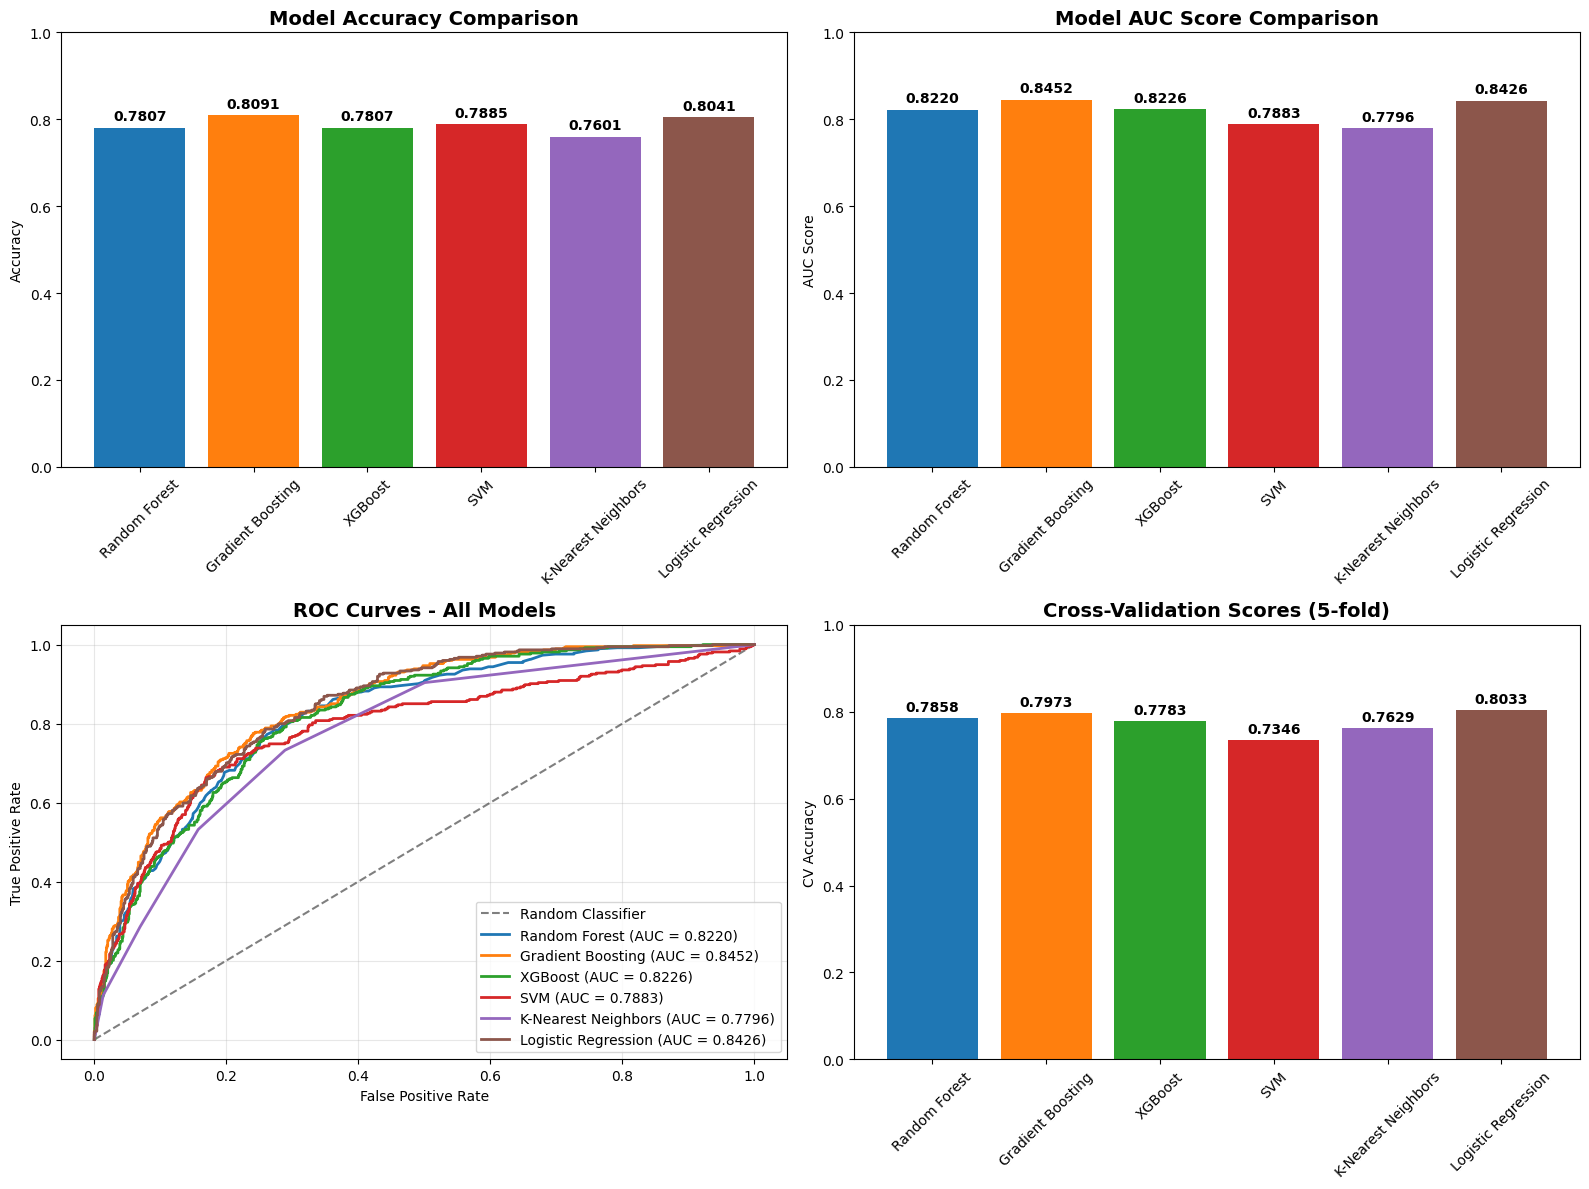


🏆 DETAILED ANALYSIS - BEST MODEL: Gradient Boosting
Accuracy: 0.8091
AUC Score: 0.8452
CV Score: 0.7973

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



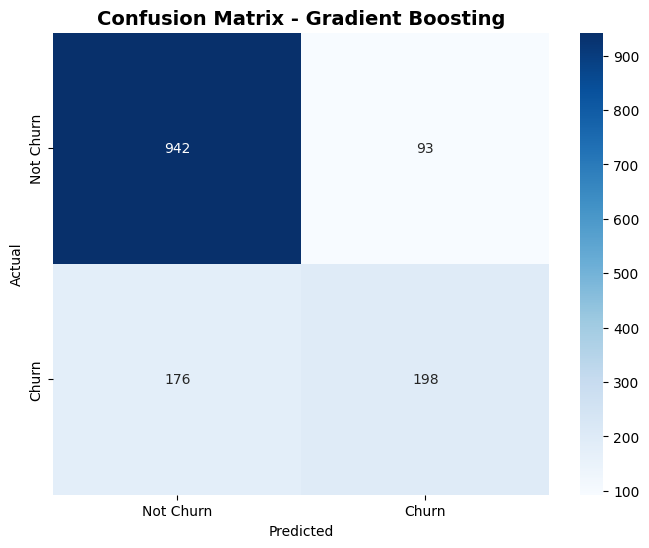


🎉 SPRINT 2 COMPLETED SUCCESSFULLY!
✅ Feature Engineering - Completed
✅ Advanced Models Training - Completed
✅ Hyperparameter Tuning - Completed
✅ Comprehensive Evaluation - Completed
📊 All models saved in: models/trained_models/

🚀 READY FOR SPRINT 3: Model Deployment & Web Application


In [1]:
# notebooks/04_advanced_models.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, roc_auc_score, roc_curve, 
                           precision_recall_curve, auc)
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("🎯 Starting Agile Sprint 2: Advanced Model Training")
print("=" * 60)

# Load engineered data
df = pd.read_csv('../data/processed/engineered_churn_data.csv')
print(f"✅ Engineered data loaded! Shape: {df.shape}")

class AdvancedModelTrainer:
    def __init__(self, data):
        self.df = data
        self.models = {}
        self.results = {}
        self.best_model = None
        self.best_score = 0
        
    def prepare_data(self):
        """Prepare data for advanced modeling"""
        print("🧹 Preparing data for advanced models...")
        
        df_encoded = self.df.copy()
        
        # Encode categorical variables
        categorical_cols = df_encoded.select_dtypes(include=['object']).columns
        print(f"📋 Encoding {len(categorical_cols)} categorical columns...")
        
        self.label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            self.label_encoders[col] = le
        
        # Separate features and target
        X = df_encoded.drop('Churn', axis=1)
        y = df_encoded['Churn']
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # Scale features
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        print(f"📊 Data prepared:")
        print(f"   Training set: {X_train.shape[0]} samples")
        print(f"   Testing set: {X_test.shape[0]} samples") 
        print(f"   Features: {X_train.shape[1]}")
        
        return X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test
    
    def train_advanced_models(self):
        """Train multiple advanced models"""
        X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test = self.prepare_data()
        
        # Define advanced models
        models = {
            'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
            'SVM': SVC(probability=True, random_state=42),
            'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
        }
        
        print("\n🚀 Training Advanced Models...")
        print("=" * 50)
        
        for name, model in models.items():
            print(f"📈 Training {name}...")
            
            try:
                # Train model
                if name in ['SVM', 'K-Nearest Neighbors', 'Logistic Regression']:
                    model.fit(X_train_scaled, y_train)
                    y_pred = model.predict(X_test_scaled)
                    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
                else:
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    y_pred_proba = model.predict_proba(X_test)[:, 1]
                
                # Calculate metrics
                accuracy = accuracy_score(y_test, y_pred)
                auc_score = roc_auc_score(y_test, y_pred_proba)
                
                # Cross-validation score
                cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
                cv_mean = cv_scores.mean()
                
                # Store results
                self.results[name] = {
                    'model': model,
                    'accuracy': accuracy,
                    'auc_score': auc_score,
                    'cv_mean': cv_mean,
                    'predictions': y_pred,
                    'probabilities': y_pred_proba,
                    'true_values': y_test
                }
                
                print(f"   ✅ {name}:")
                print(f"      Accuracy: {accuracy:.4f}")
                print(f"      AUC Score: {auc_score:.4f}")
                print(f"      CV Score: {cv_mean:.4f}")
                
                # Update best model
                if accuracy > self.best_score:
                    self.best_score = accuracy
                    self.best_model = name
                
                # Save model
                model_filename = f'../models/trained_models/{name.replace(" ", "_").lower()}_advanced.pkl'
                joblib.dump(model, model_filename)
                
            except Exception as e:
                print(f"   ❌ Error training {name}: {e}")
        
        print(f"\n🏆 BEST MODEL: {self.best_model} (Accuracy: {self.best_score:.4f})")
        return self.results
    
    def hyperparameter_tuning(self):
        """Perform hyperparameter tuning on best model"""
        print("\n🎯 Performing Hyperparameter Tuning...")
        
        X_train_scaled, X_test_scaled, X_train, X_test, y_train, y_test = self.prepare_data()
        
        if self.best_model == 'Random Forest':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
            model = RandomForestClassifier(random_state=42)
        
        elif self.best_model == 'XGBoost':
            param_grid = {
                'n_estimators': [100, 200],
                'max_depth': [3, 6, 9],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 1.0]
            }
            model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
        
        else:
            print("⚠️  Hyperparameter tuning for other models skipped for time")
            return None
        
        print(f"🔧 Tuning {self.best_model}...")
        grid_search = GridSearchCV(
            model, param_grid, cv=5, scoring='accuracy', 
            n_jobs=-1, verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        
        print(f"✅ Best parameters: {grid_search.best_params_}")
        print(f"✅ Best cross-validation score: {grid_search.best_score_:.4f}")
        
        # Train with best parameters
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        print(f"✅ Test accuracy with tuned parameters: {accuracy:.4f}")
        
        # Save tuned model
        joblib.dump(best_model, f'../models/trained_models/{self.best_model.replace(" ", "_").lower()}_tuned.pkl')
        
        return best_model
    
    def comprehensive_evaluation(self):
        """Comprehensive model evaluation with visualizations"""
        print("\n📊 COMPREHENSIVE MODEL EVALUATION")
        print("=" * 50)
        
        # Create comparison table
        comparison_data = []
        for name, result in self.results.items():
            comparison_data.append({
                'Model': name,
                'Accuracy': f"{result['accuracy']:.4f}",
                'AUC Score': f"{result['auc_score']:.4f}",
                'CV Score': f"{result['cv_mean']:.4f}"
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print("📈 MODEL PERFORMANCE COMPARISON:")
        print(comparison_df.to_string(index=False))
        
        # Visualization 1: Model Comparison
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Accuracy comparison
        models = list(self.results.keys())
        accuracies = [self.results[name]['accuracy'] for name in models]
        
        bars = axes[0, 0].bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
        axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold', fontsize=14)
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].set_ylim(0, 1)
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        for bar, accuracy in zip(bars, accuracies):
            axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')
        
        # AUC comparison
        auc_scores = [self.results[name]['auc_score'] for name in models]
        
        bars = axes[0, 1].bar(models, auc_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
        axes[0, 1].set_title('Model AUC Score Comparison', fontweight='bold', fontsize=14)
        axes[0, 1].set_ylabel('AUC Score')
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        for bar, auc in zip(bars, auc_scores):
            axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{auc:.4f}', ha='center', va='bottom', fontweight='bold')
        
        # ROC Curves
        axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
        for name, result in self.results.items():
            fpr, tpr, _ = roc_curve(result['true_values'], result['probabilities'])
            auc_score = result['auc_score']
            axes[1, 0].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)
        
        axes[1, 0].set_xlabel('False Positive Rate')
        axes[1, 0].set_ylabel('True Positive Rate')
        axes[1, 0].set_title('ROC Curves - All Models', fontweight='bold', fontsize=14)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Cross-Validation Scores
        cv_scores = [self.results[name]['cv_mean'] for name in models]
        
        bars = axes[1, 1].bar(models, cv_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
        axes[1, 1].set_title('Cross-Validation Scores (5-fold)', fontweight='bold', fontsize=14)
        axes[1, 1].set_ylabel('CV Accuracy')
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        for bar, cv in zip(bars, cv_scores):
            axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                          f'{cv:.4f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../models/model_performance/advanced_models_comparison.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Best Model Detailed Analysis
        best_result = self.results[self.best_model]
        print(f"\n🏆 DETAILED ANALYSIS - BEST MODEL: {self.best_model}")
        print("=" * 50)
        print(f"Accuracy: {best_result['accuracy']:.4f}")
        print(f"AUC Score: {best_result['auc_score']:.4f}")
        print(f"CV Score: {best_result['cv_mean']:.4f}")
        
        print("\n📋 Classification Report:")
        print(classification_report(best_result['true_values'], best_result['predictions']))
        
        # Confusion Matrix for Best Model
        cm = confusion_matrix(best_result['true_values'], best_result['predictions'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Not Churn', 'Churn'],
                   yticklabels=['Not Churn', 'Churn'])
        plt.title(f'Confusion Matrix - {self.best_model}', fontweight='bold', fontsize=14)
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.savefig('../models/model_performance/best_model_confusion_matrix.png', 
                   dpi=300, bbox_inches='tight')
        plt.show()

# Execute Advanced Model Training
print("🚀 Starting advanced model training...")
trainer = AdvancedModelTrainer(df)

# Train advanced models
results = trainer.train_advanced_models()

# Perform hyperparameter tuning
tuned_model = trainer.hyperparameter_tuning()

# Comprehensive evaluation
trainer.comprehensive_evaluation()

print("\n🎉 SPRINT 2 COMPLETED SUCCESSFULLY!")
print("=" * 50)
print("✅ Feature Engineering - Completed")
print("✅ Advanced Models Training - Completed") 
print("✅ Hyperparameter Tuning - Completed")
print("✅ Comprehensive Evaluation - Completed")
print("📊 All models saved in: models/trained_models/")
print("\n🚀 READY FOR SPRINT 3: Model Deployment & Web Application")